# 🚀 8강. ResNet-18 파인튜닝 — 소리를 진짜 이미지로 (AI Pair) 💡

> 📌 **이 노트북의 목표**
> - 5~7강에서 CSV 피처(RandomForest)로 만든 baseline을, 이번엔 **멜스펙트로그램 PNG를 진짜 이미지처럼 다루는 ResNet-18 fine-tuning**으로 끌어올립니다.
> - `ImageFolder` → `DataLoader` → 학습 루프 → RF와의 수치 비교까지, Phase 0~1의 마지막 실습입니다.
> - GPU가 없어도(`RUN_HEAVY=False`) 시뮬레이션 데이터로 전체 파이프라인을 처음부터 끝까지 체험합니다.

> 📍 **앞 노트북(5~7강)** 에서 만든 것 — 5강 CSV+RandomForest(RF_ACCURACY=85.99%, 섹션 5 'RF vs ResNet-18 성능 비교'에서 재계산), 6강 Streamlit 앱, 7강 ResNet-18 구조 이해 — 가 이번 강에서 실제로 학습되는 모델로 이어집니다.

> 🧭 **이 강이 다루지 않는 것**
> - 실제 GPU 학습의 세부 튜닝(learning rate 탐색, mixup 같은 고급 증강) — 이 강은 fine-tuning의 "표준 레시피" 하나만 다룹니다.
> - 음성 인식(STT)·LLM 에이전트 통합 — 오디오·이미지 분류로 이뤄진 Phase 0~1은 이 강에서 마무리되고, 이후 과정에서 텍스트·음성 모달리티와 에이전트로 확장됩니다.
> - 지금은 "전이학습으로 이미지 분류를 실제로 완성한다"에만 집중하세요.

> 📋 **오늘의 계약(contract)** — 이 다섯 줄이 맞으면 절반은 성공입니다
> 1. **입력**: PIL Image → `Resize(224,224)` + ImageNet 정규화 → (3, 224, 224) float32 텐서
> 2. **배치**: (B, 3, 224, 224) — B = BATCH_SIZE(32)
> 3. **모델 출력**: (B, 10) **로짓**(확률 아님) — 10개 장르
> 4. **손실 계약**: `nn.CrossEntropyLoss(label_smoothing=0.1)` — 로짓을 그대로 입력
> 5. **게이트**: `RUN_HEAVY=False`(기본) → 시뮬레이션 값 / `True` → 실제 학습(GPU 권장)

---
<a id='runheavy'></a>
## RUN_HEAVY 게이트 안내

이 노트북의 학습 셀은 `if RUN_HEAVY:` 블록으로 보호됩니다.

```
RUN_HEAVY = False (기본)  →  시뮬레이션 결과만 출력 (CPU 안전)
RUN_HEAVY = True          →  실제 학습 실행 (GPU 권장, ~15~30분)
```

**GPU 환경으로 바꾸는 법:**
- Google Colab: 런타임 > 런타임 유형 변경 > GPU
- 로컬: CUDA 또는 Apple MPS가 있으면 자동 감지
- 수동 강제: 다음 셀에서 `RUN_HEAVY = True`로 변경

In [1]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 1] RUN_HEAVY 설정 — 여기서만 바꾸면 됩니다     │
# │ False: 시뮬레이션 모드 (CPU 안전, 빠름)               │
# │ True : 실제 학습 (GPU 권장, 15~30분)                  │
# └────────────────────────────────────────────────────────┘

# [학생] 이 값을 바꿔서 실행하세요
RUN_HEAVY = False  # ← GPU 보유 시 True로 변경

print(f'RUN_HEAVY = {RUN_HEAVY}')
if RUN_HEAVY:
    print('  ★★ 실제 학습 모드 — 학습 루프가 실행됩니다 (GPU 권장)')
else:
    print('  ★  시뮬레이션 모드 — 학습 결과를 미리 보여줍니다')
    print('  GPU 환경에서 실행: RUN_HEAVY = True 로 변경 후 커널 재시작')

RUN_HEAVY = False
  ★  시뮬레이션 모드 — 학습 결과를 미리 보여줍니다
  GPU 환경에서 실행: RUN_HEAVY = True 로 변경 후 커널 재시작


In [2]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 2] 패키지 설치                                  │
# └────────────────────────────────────────────────────────┘
import subprocess, sys

packages = ['torch', 'torchvision', 'librosa', 'scikit-learn',
            'seaborn', 'tqdm', 'joblib', 'Pillow']

for pkg in packages:
    import_name = pkg.replace('-', '_').lower()
    if import_name == 'pillow':
        import_name = 'PIL'
    try:
        __import__(import_name)
        print(f'[OK] {pkg}')
    except ImportError:
        print(f'[설치 중] {pkg} ...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
        print(f'[완료] {pkg}')

print('\n패키지 준비 완료!')

[OK] torch


[OK] torchvision
[OK] librosa
[설치 중] scikit-learn ...



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


[완료] scikit-learn


[OK] seaborn
[OK] tqdm
[OK] joblib
[OK] Pillow

패키지 준비 완료!


In [3]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3a] 전역 초기화 (1/3) — import + 재현성 시드     │
# └────────────────────────────────────────────────────────┘
import os, sys, platform, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, TensorDataset
from pathlib import Path
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# ── 재현성 시드 고정 (항상 첫 번째!) ──────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

print('[셀 3a] import + seed(42) 고정 완료')


[셀 3a] import + seed(42) 고정 완료


In [4]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3b-1] 한글 폰트 후보 목록 — OS별 폰트명 + 파일경로 │
# └────────────────────────────────────────────────────────┘
# [왜] matplotlib 기본 폰트는 한글을 지원하지 않음 → 그래프 라벨이 네모(□)로 깨짐
#      OS별로 설치된 한글 폰트가 다르므로 후보 목록을 먼저 데이터로 분리해두고
#      다음 셀에서 순서대로 탐색해 첫 매치를 사용
# (matplotlib 자체는 셀 3a에서 이미 import됨 — 여기서는 font_manager 서브모듈만 추가)

import matplotlib.font_manager as fm

_KOREAN_FONT_NAMES = {
    "Darwin": [
        "AppleGothic", "Apple SD Gothic Neo", "NanumGothic",
        "Noto Sans CJK KR", "Noto Sans KR",
    ],
    "Windows": [
        "Malgun Gothic", "맑은 고딕", "NanumGothic",
        "Noto Sans CJK KR", "Noto Sans KR",
    ],
    "Linux": [
        "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
        "Noto Sans CJK JP", "Noto Sans CJK SC",
    ],
}

_KOREAN_FONT_FILES = {
    "Darwin": [
        "/System/Library/Fonts/AppleGothic.ttf",
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
        "/Library/Fonts/NanumGothic.ttf",
        str(Path.home() / "Library/Fonts/NanumGothic.ttf"),
    ],
    "Windows": [
        "C:/Windows/Fonts/malgun.ttf",
        "C:/Windows/Fonts/NanumGothic.ttf",
    ],
    "Linux": [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/noto/NotoSansKR-Regular.otf",
    ],
}

print('[데이터 준비 완료] OS별 한글 폰트 후보 목록')


[데이터 준비 완료] OS별 한글 폰트 후보 목록


In [5]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3b-2] 한글 폰트 탐지 함수                          │
# └────────────────────────────────────────────────────────┘
def _detect_korean_font():
    """OS별 후보 목록(셀 3b-1)을 탐색해 사용 가능한 한글 폰트명을 반환."""
    system = platform.system()

    for font_path in _KOREAN_FONT_FILES.get(system, []):
        if Path(font_path).exists():
            fm.fontManager.addfont(font_path)

    available = {f.name for f in fm.fontManager.ttflist}
    candidates = _KOREAN_FONT_NAMES.get(system, []) + [
        "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
        "AppleGothic", "Malgun Gothic",
    ]
    chosen = next((font for font in candidates if font in available), None)

    # Linux(Colab GPU 환경 포함)엔 한글 폰트가 기본 설치돼 있지 않을 수 있어, 후보 폰트가
    # 하나도 없으면 apt-get으로 나눔고딕을 설치한 뒤 다시 탐색합니다.
    if chosen is None and system == "Linux":
        import os
        os.system("apt-get -qq -y install fonts-nanum > /dev/null 2>&1")
        for _fp in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(_fp)
        available = {f.name for f in fm.fontManager.ttflist}
        chosen = next((font for font in candidates if font in available), None)

    if chosen is None:
        chosen = "DejaVu Sans"
        print("[폰트 경고] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨지면 NanumGothic 또는 Noto Sans CJK KR을 설치하세요.")
    return chosen

print('[함수 정의 완료] _detect_korean_font() -> str')


[함수 정의 완료] _detect_korean_font() -> str


In [6]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3b-3] 한글 폰트 적용 — matplotlib·seaborn 전역 설정 │
# └────────────────────────────────────────────────────────┘
# [왜] 탐지된 폰트명을 rcParams·seaborn theme에 반영해야 그래프에 실제로 적용됨

def setup_korean_font():
    chosen = _detect_korean_font()
    matplotlib.rcParams["font.family"] = chosen
    matplotlib.rcParams["font.sans-serif"] = [
        chosen, "NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic", "DejaVu Sans",
    ]
    matplotlib.rcParams["axes.unicode_minus"] = False
    try:
        import seaborn as sns
        sns.set_theme(
            style="whitegrid",
            rc={
                "font.family": chosen,
                "font.sans-serif": [
                    chosen, "NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic", "DejaVu Sans",
                ],
                "axes.unicode_minus": False,
            },
        )
    except Exception:
        pass
    return chosen

KOREAN_FONT = setup_korean_font()
print(f"[폰트] {KOREAN_FONT}")


[폰트] AppleGothic


In [7]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3c-1] 디바이스 감지 (MPS → CUDA → CPU)             │
# └────────────────────────────────────────────────────────┘
_system = platform.system()  # 'Darwin', 'Linux', 'Windows'
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif _system == 'Darwin' and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'[디바이스] {DEVICE}')

# RUN_HEAVY 유효성 확인 (GPU 없는데 True면 경고)
if RUN_HEAVY and DEVICE.type == 'cpu':
    print('[경고] RUN_HEAVY=True이지만 CPU 환경입니다 — 학습이 매우 느릴 수 있습니다')
    print('       Colab GPU 환경을 권장합니다')


[디바이스] mps


In [8]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3c-2] 데이터 경로 설정                              │
# └────────────────────────────────────────────────────────┘
# cwd와 상위 폴더 중 실제로 Data/가 있는 쪽을 NB_DIR로 씁니다(Data/·모델 파일은 AI_Music/ 루트에 있습니다).
_cwd, _parent = Path('.').resolve(), Path('..').resolve()
NB_DIR = _cwd if (_cwd / 'Data').exists() else _parent
DATA_ROOT = NB_DIR / 'Data/Music_genres'
CSV_PATH  = DATA_ROOT / 'features_3_sec.csv'
WAV_ROOT  = DATA_ROOT / 'genres_original'
PNG_ROOT  = DATA_ROOT / 'images_original'
MODEL_PATH = NB_DIR / 'model_rf.joblib'
LE_PATH    = NB_DIR / 'label_encoder.joblib'
SC_PATH    = NB_DIR / 'scaler.joblib'
RESNET_SAVE_PATH = NB_DIR / 'resnet18_gtzan.pth'

print(f'[경로] PNG_ROOT 존재: {PNG_ROOT.exists()}')
print(f'       CSV 존재: {CSV_PATH.exists()}')
print(f'       RF 모델 존재: {MODEL_PATH.exists()}')


[경로] PNG_ROOT 존재: True
       CSV 존재: True
       RF 모델 존재: True


In [9]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 3c-3] 색상 팔레트 + 장르 목록                       │
# └────────────────────────────────────────────────────────┘
COLORS = {
    'primary':   '#2563EB',
    'secondary': '#7C3AED',
    'accent':    '#059669',
    'neutral':   '#6B7280',
    'warning':   '#F59E0B',
}
GENRES = ['blues','classical','country','disco','hiphop',
          'jazz','metal','pop','reggae','rock']

print('\n초기화 완료!')



초기화 완료!


---
<a id='sec1'></a>
## 섹션 1 — 데이터 준비: ImageFolder + DataLoader

### 왜 ImageFolder인가?

> 5강에서는 CSV를 pandas로 읽었습니다. 이번엔 PNG 이미지 폴더입니다.
> `ImageFolder`는 **디렉토리명 = 클래스명**으로 자동 매핑합니다:
> ```
> images_original/
>   blues/     ← 클래스 0 (알파벳 순)
>     blues00000.png
>   classical/ ← 클래스 1
>     ...
> ```
> 폴더 구조만 맞으면 `pd.read_csv()`처럼 한 줄로 로드됩니다.

### 이전 세션과 연결

5강에서 만든 멜스펙트로그램 PNG는 이미지 분류 모델의 입력이 됩니다.
8강에서는 `ImageFolder(root=PNG_ROOT)`로 폴더 구조를 읽어 장르 레이블을 자동 매핑합니다.
원리는 단순합니다 — 디렉토리가 레이블, 파일이 샘플입니다.

> 💡 [4강 회상] 4강에서 본 멜스펙트로그램 이미지(시간 × 주파수 2D 행렬)가
> 그대로 ResNet의 입력 텐서가 됩니다. 즉 4강 = ResNet 입력 형식의 직관,
> 8강 = 그 이미지를 진짜 이미지 분류 모델에 먹이는 단계.

> 📐 **코드를 읽기 전에 — Transform 파이프라인이 하는 일**
>
> | 코드 | 하는 일 | 왜 필요한가 |
> |---|---|---|
> | `Resize((224,224))` | 모든 이미지를 같은 크기로 통일 | ResNet-18은 고정 크기 입력을 기대 |
> | `RandomHorizontalFlip(p=0.3)` | 30% 확률로 좌우 반전 (학습셋만) | 데이터 증강 — 좌우 대칭 변형에 흔들리지 않게 |
> | `ColorJitter` | 밝기·대비를 랜덤하게 변형 (학습셋만) | 녹음·촬영 환경별 밝기/대비 변동에 강건해지도록 학습 |
> | `ToTensor()` | PIL Image → (0~1) float 텐서 | PyTorch 연산은 텐서 단위로 이뤄짐 |
> | `Normalize(mean, std)` | ImageNet 통계로 표준화 | 사전학습 가중치가 기대하는 입력 분포에 맞춤 |
> | (검증셋) | 위 파이프라인에서 Flip·Jitter만 제거 | 평가는 매번 같은 입력이어야 공정함 |

In [10]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 4] Transforms 정의 — 전이학습 표준 전처리       │
# │ 입력: PIL Image   출력: Tensor (3, 224, 224)           │
# └────────────────────────────────────────────────────────┘
# [왜] ImageNet 사전학습 모델은 특정 mean/std로 정규화된 입력을 기대함
#      Resize(224,224): ResNet 표준 입력 크기
#      Normalize: ImageNet mean/std를 그대로 적용해야 사전학습 지식 보존

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),          # 데이터 증강: 좌우 반전
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 밝기/대비 랜덤 변환
    transforms.ToTensor(),                            # [0,255] uint8 → [0,1] float32
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Train Transform:')
print(train_transform)
print()
print('Val Transform:')
print(val_transform)
print()
print('[핵심] 검증/테스트 시에는 RandomFlip, ColorJitter 없음')
print('        → 매번 같은 결과가 나와야 평가가 공정함')

Train Transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.3)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val Transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

[핵심] 검증/테스트 시에는 RandomFlip, ColorJitter 없음
        → 매번 같은 결과가 나와야 평가가 공정함


In [11]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 5-1] ImageFolder 로드 시도 — train/val split       │
# │ 입력: images_original/ 폴더                            │
# │ 출력: train_dataset, val_dataset_clean (성공 시)        │
# └────────────────────────────────────────────────────────┘
# [왜] random_split으로 80/20 분리 — Generator seed 고정으로 재현성 확보

BATCH_SIZE = 32
USING_REAL_PNG = False

if PNG_ROOT.exists():
    try:
        full_dataset = ImageFolder(str(PNG_ROOT), transform=train_transform)
        n_total = len(full_dataset)
        n_val   = int(n_total * 0.2)
        n_train = n_total - n_val

        train_dataset, val_dataset = random_split(
            full_dataset, [n_train, n_val],
            generator=torch.Generator().manual_seed(SEED)
        )

        # 검증셋은 augmentation 없이
        # random_split은 dataset 공유 → transform을 직접 바꿀 수 없음
        # 해결: Subset wrapper 또는 별도 ImageFolder
        val_full = ImageFolder(str(PNG_ROOT), transform=val_transform)
        val_dataset_clean = torch.utils.data.Subset(
            val_full, val_dataset.indices
        )

        CLASS_NAMES = full_dataset.classes
        USING_REAL_PNG = True
        print(f'[ImageFolder 로드 성공]')
        print(f'  전체: {n_total}장  (train={n_train}, val={n_val})')
        print(f'  클래스: {CLASS_NAMES}')
        print(f'  클래스-인덱스: {full_dataset.class_to_idx}')

    except Exception as e:
        print(f'[경고] ImageFolder 로드 실패: {e}')


[ImageFolder 로드 성공]
  전체: 937장  (train=750, val=187)
  클래스: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
  클래스-인덱스: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [12]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 5-2] 폴백 — PNG 없을 때 더미 TensorDataset 생성    │
# │ 입력: USING_REAL_PNG (셀 5-1)                          │
# │ 출력: train_dataset, val_dataset_clean                 │
# └────────────────────────────────────────────────────────┘
if not USING_REAL_PNG:
    print('[폴백] PNG 폴더 없음 → 더미 TensorDataset 생성')
    N_DUMMY = 300
    dummy_X = torch.randn(N_DUMMY, 3, IMG_SIZE, IMG_SIZE)
    dummy_y = torch.randint(0, 10, (N_DUMMY,))
    dummy_ds = TensorDataset(dummy_X, dummy_y)
    n_val   = int(N_DUMMY * 0.2)
    n_train = N_DUMMY - n_val
    train_dataset, val_dataset_clean = random_split(
        dummy_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )
    CLASS_NAMES = GENRES
    print(f'  더미 데이터: train={n_train}, val={n_val}')


> 🔍 **ImageFolder 구조 해석**
> - `class_to_idx`: 폴더명을 알파벳 순으로 0~9에 매핑 — blues=0, classical=1, ..., rock=9
> - `random_split`의 Generator seed 고정: 매 실행마다 같은 학습/검증 분할을 보장
> - 검증셋 transform 분리: 증강(Flip/Jitter)을 검증에 쓰면 매 에포크마다 다른 결과 → 공정한 평가 불가

In [13]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 6-1] DataLoader 생성 + 배치 shape 확인             │
# │ 입력: train_dataset, val_dataset_clean                 │
# │ 출력: train_loader, val_loader                         │
# └────────────────────────────────────────────────────────┘
# [왜] pin_memory=True (CUDA): CPU→GPU 데이터 전송을 pinned memory로 가속
#      num_workers=0: Jupyter 환경 호환 (process fork 이슈 방지)

_pin = (DEVICE.type == 'cuda')

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=_pin
)
val_loader = DataLoader(
    val_dataset_clean, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=_pin
)

# 첫 배치 shape 확인
sample_imgs, sample_labels = next(iter(train_loader))
print(f'배치 shape: 이미지={sample_imgs.shape}, 레이블={sample_labels.shape}')
print(f'  이미지 dtype={sample_imgs.dtype}, 범위=[{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]')
print(f'  레이블 분포: {torch.bincount(sample_labels).tolist()}')


배치 shape: 이미지=torch.Size([32, 3, 224, 224]), 레이블=torch.Size([32])
  이미지 dtype=torch.float32, 범위=[-2.12, 2.64]
  레이블 분포: [5, 4, 6, 1, 4, 0, 2, 4, 2, 4]


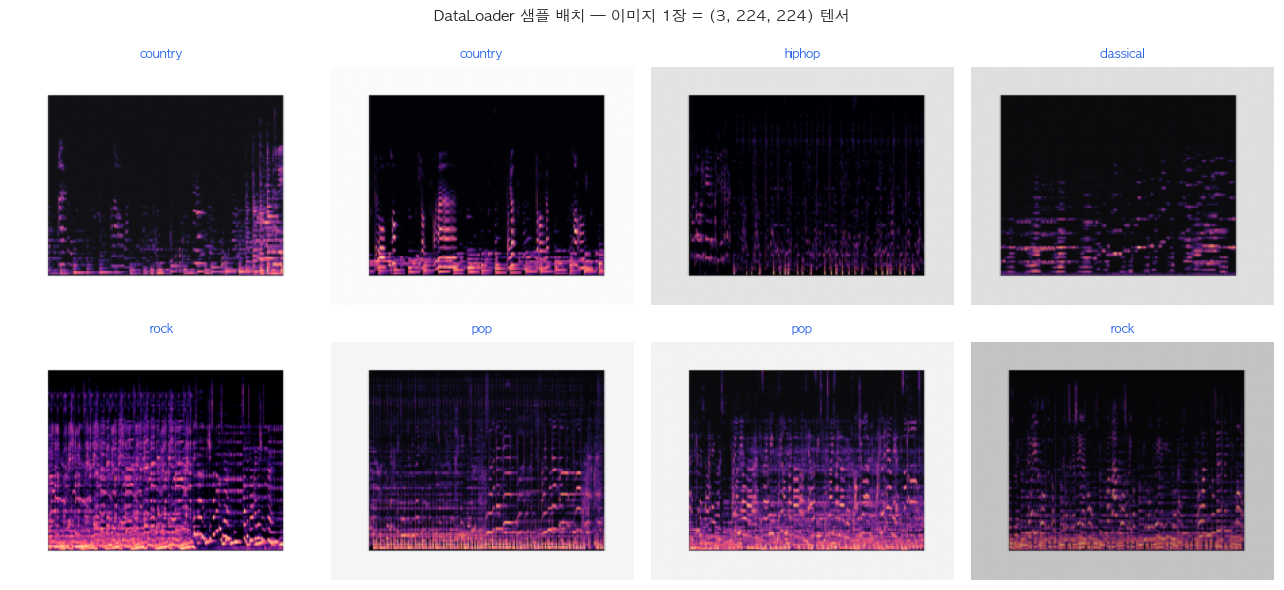


[학생 실험] BATCH_SIZE=64로 바꾸면 배치 shape이 어떻게 달라지나요?


In [14]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 6-2] 샘플 배치 시각화 (4×2 그리드)                  │
# │ 입력: sample_imgs, sample_labels (셀 6-1)               │
# │ 출력: 역정규화된 샘플 이미지 8장                        │
# └────────────────────────────────────────────────────────┘
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

n_show = min(8, len(sample_imgs))
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        img = denormalize(sample_imgs[i]).permute(1, 2, 0).numpy()
        ax.imshow(img if img.max() > 0 else np.zeros_like(img) + 0.5,
                  aspect='auto')
        lbl = sample_labels[i].item()
        genre = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else f'cls{lbl}'
        ax.set_title(genre, fontsize=9, color=COLORS['primary'])
    ax.axis('off')
plt.suptitle(f'DataLoader 샘플 배치 — 이미지 1장 = (3, {IMG_SIZE}, {IMG_SIZE}) 텐서',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n[학생 실험] BATCH_SIZE=64로 바꾸면 배치 shape이 어떻게 달라지나요?')


> 🔍 **DataLoader 배치 결과 해석**
> - shape `(32, 3, 224, 224)`: 배치 32장 × RGB 3채널 × 224×224 픽셀
> - 범위 [-2.1, 2.6]: ImageNet 정규화 후 값 — pixel이 아닌 표준화된 수치
> - 레이블 분포가 고른지 확인: 불균형하면 `WeightedRandomSampler`가 필요

> 💡 **왜 ImageNet(강아지·자동차 사진)으로 학습한 모델이 멜스펙트로그램에도 통할까?**
>
> ResNet-18의 앞쪽 레이어(conv1~layer2)는 "모서리·줄무늬·색 그라디언트 같은 저수준 시각 패턴"을 감지하도록 학습되어 있습니다. 사진이 강아지든 자동차든 멜스펙트로그램이든 상관없이 **이미지라면 공통으로 나타나는 패턴**입니다 — 사람이 어떤 언어의 알파벳(선·곡선의 조합)을 한 번 익히면, 처음 보는 단어도 곧바로 읽을 수 있는 것과 비슷합니다.
>
> 멜스펙트로그램은 가로축=시간, 세로축=주파수, 색=에너지 강도인 이미지입니다. 리듬이 강한 구간은 세로 줄무늬로, 음이 길게 지속되는 구간은 가로 띠로 나타납니다 — ResNet-18이 ImageNet에서 이미 배운 "줄무늬·경계·질감 감지" 능력을 그대로 재사용할 수 있는 이유입니다. 그래서 뒤쪽 레이어(layer3~fc)만 우리 데이터(장르)에 맞게 다시 학습시키면 됩니다 — 이것이 바로 **전이학습(transfer learning)**입니다.


---
<a id='sec2'></a>
## 섹션 2 — ResNet-18 모델 구성 + 전이학습 3단계

### 전이학습 3단계 전략

```
단계 1 (Feature Extractor):  backbone 동결, FC만 학습
  → 데이터 매우 적을 때 (< 500장)
  → 학습 빠름, 과적합 낮음

단계 2 (Partial Fine-tuning): 마지막 1~2 레이어 해제, FC 학습
  → 데이터 적당할 때 (500~5000장)
  → 균형 잡힌 선택

단계 3 (Full Fine-tuning):   전체 학습 (8강에서 실행)
  → 데이터 충분할 때 (GTZAN 전체 937장, 장르당 평균 ~94장)
  → 가장 높은 성능, GPU 필요
```

**→ 실무 결론:** GTZAN(전체 937장, 장르당 평균 ~94장)은 단계 3이 적합. 단, 작은 lr=1e-4로 사전학습 가중치 보존.

> ▶ **실행 전 예측** — 아래 셀을 실행하기 전에 먼저 적어보세요.
> - `extractor`(FC만 학습) vs `full`(전체 파인튜닝) — GTZAN처럼 각 장르 평균 94장(전체 937장) 정도 있을 때, 어느 전략이 더 높은 정확도를 낼까요?
> - 학습 가능 파라미터 비율이 0.05%(extractor)에서 100%(full)로 커지면, 학습 시간도 그 비율만큼 차이 날까요?
>
> 💡 정답은 다음 셀 실행 후 "🔍 해석" 박스에서 확인합니다.

In [15]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 7a-1] 전이학습 전략별 파라미터 동결 헬퍼           │
# └────────────────────────────────────────────────────────┘
# [왜] build_model()이 너무 길어지지 않도록 "동결 로직"만 별도 함수로 분리

def _configure_trainable_params(model, strategy: str):
    """
    strategy:
      'extractor' — backbone 동결, FC만 학습
      'partial'   — Layer4 + FC 학습
      'full'      — 전체 파인튜닝 (동결 없음)
    """
    if strategy == 'extractor':
        # 전체 동결
        for param in model.parameters():
            param.requires_grad = False

    elif strategy == 'partial':
        # backbone 동결 후 Layer4만 해제
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True

    # strategy == 'full'이면 아무것도 동결하지 않음 (기본 requires_grad=True 유지)
    return model

print('[함수 정의 완료] _configure_trainable_params(model, strategy) -> nn.Module')


[함수 정의 완료] _configure_trainable_params(model, strategy) -> nn.Module


In [16]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 7a-2] build_model() 정의 — 전이학습 3단계 지원     │
# │ 입력: 없음   출력: nn.Module (DEVICE로 이동)           │
# └────────────────────────────────────────────────────────┘
# [왜] 단계 선택을 함수 파라미터로 추상화 → 실험 반복이 쉬움

def build_model(
    n_classes: int = 10,
    strategy: str = 'full',   # 'extractor' | 'partial' | 'full'
    dropout: float = 0.3
) -> nn.Module:
    """
    전이학습 전략별 ResNet-18 모델 반환. (동결 로직은 셀 7a-1의 _configure_trainable_params 참고)
    """
    try:
        from torchvision.models import ResNet18_Weights
        model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    except ImportError:
        model = models.resnet18(pretrained=True)

    model = _configure_trainable_params(model, strategy)

    # FC 교체 (동결 해제 포함)
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_feat, n_classes)
    )
    # FC는 항상 학습 가능
    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(DEVICE)
    return model

print('[함수 정의 완료] build_model(n_classes=10, strategy=\'full\', dropout=0.3) -> nn.Module')


[함수 정의 완료] build_model(n_classes=10, strategy='full', dropout=0.3) -> nn.Module


In [17]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 7b] 전략별 파라미터 수 비교 (실행)               │
# │ 입력: build_model()   출력: 비교표 + 8강 학습용 model   │
# └────────────────────────────────────────────────────────┘
# [왜] extractor/partial/full 세 전략의 "학습 가능 파라미터 비율"을
#      직접 측정해야 실행 전 예측(바로 위 질문)이 맞았는지 확인할 수 있음

print('전이학습 전략별 학습 가능 파라미터 수 비교:\n')
print(f'{"전략":<15} {"학습가능":>12} {"전체":>12} {"비율":>8}')
print('-' * 50)

strategy_stats = {}
for strat in ['extractor', 'partial', 'full']:
    m = build_model(strategy=strat)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    ratio     = trainable / total * 100
    strategy_stats[strat] = ratio
    print(f'{strat:<15} {trainable:>12,} {total:>12,} {ratio:>7.1f}%')

print()
# [왜 f-string인가] 아래 문장을 강사가 손으로 쓴 숫자가 아니라
#                    바로 위 표에서 실제로 측정한 strategy_stats 값으로 채움
#                    → 모델 구조가 바뀌어도 해석 문구가 저절로 정확해짐
print(f"[핵심] extractor 전략: FC(~5K)만 학습 — 전체의 {strategy_stats['extractor']:.2f}% — 데이터 적어도 과적합 낮음")
print(f"[핵심] partial 전략: Layer4+FC 학습 — ResNet-18은 파라미터 대부분이 layer4에 몰려 있어 "
      f"전체의 {strategy_stats['partial']:.1f}%나 됩니다 (이름과 달리 '중간'이 아니라 이미 full에 가까운 학습량)")
print(f"[핵심] full 전략: {strategy_stats['full']:.0f}% 전부 학습 — 데이터 충분하면 가장 높은 성능")

# 8강 실제 학습에 쓸 모델 (full fine-tuning)
model = build_model(strategy='full', dropout=0.3)
print(f'\n[8강 학습용] 전략=full, 디바이스={DEVICE}')


전이학습 전략별 학습 가능 파라미터 수 비교:

전략                      학습가능           전체       비율
--------------------------------------------------


extractor              5,130   11,181,642     0.0%
partial            8,398,858   11,181,642    75.1%


full              11,181,642   11,181,642   100.0%

[핵심] extractor 전략: FC(~5K)만 학습 — 전체의 0.05% — 데이터 적어도 과적합 낮음
[핵심] partial 전략: Layer4+FC 학습 — ResNet-18은 파라미터 대부분이 layer4에 몰려 있어 전체의 75.1%나 됩니다 (이름과 달리 '중간'이 아니라 이미 full에 가까운 학습량)
[핵심] full 전략: 100% 전부 학습 — 데이터 충분하면 가장 높은 성능

[8강 학습용] 전략=full, 디바이스=mps


> 🔍 **전이학습 3단계 파라미터 비교 해석**
> - extractor: FC(~5K)만 학습 — 전체 파라미터의 0.05%(위 표에서는 소수점 반올림으로 0.0%로 표시) — 수십 장 데이터에도 안전
> - partial: Layer4+FC 학습 — ResNet-18은 파라미터 대부분이 마지막 블록(layer4)에 몰려 있어, "일부만 푼다"는 이름과 달리 실제로는 전체의 약 75.1%(위 표 참고)를 학습합니다 — 중간 수준이 아니라 이미 full에 가까운 학습량입니다.
> - full: 100% — GTZAN처럼 각 장르 평균 94장(전체 937장) 정도면 시도 가능
> - 실무 기준: 데이터 < 500장/클래스 → extractor부터, 이후 성능 보면서 해제 범위 확대
> - 예측과 비교: 학습 가능 파라미터 비율(0.05% → 75.1% → 100%)과 학습 **시간**은 비례하지 않습니다 — extractor는 forward는 전체를 타지만 backward(역전파)가 FC까지만 이뤄져 시간이 크게 줄어듭니다. 반면 **정확도**는 데이터가 충분한 GTZAN에서는 보통 full이 가장 높습니다.


---
<a id='sec3'></a>
## 섹션 3 — 학습 루프 + 검증 루프 (RUN_HEAVY 보호)

### 왜 `model.train()` / `model.eval()`을 구분하는가?

> `model.train()`: Dropout이 랜덤으로 뉴런을 끔 (regularization)
> `model.eval()`: Dropout 끄고 모든 뉴런 사용 — 예측 일관성
> 이 두 줄을 빠뜨리면 검증 결과가 매 에포크마다 달라지는 버그가 생깁니다.

In [18]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 8-1] train_one_epoch() 함수 정의                   │
# │ 입력: model, loader, criterion, optimizer             │
# │ 출력: 평균 손실값 (float)                              │
# └────────────────────────────────────────────────────────┘
# [왜] 학습 루프를 함수로 분리 → epoch loop 본문이 깔끔해짐
#      gradient accumulation 패턴도 이 함수 안에서 적용 가능

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion,
    optimizer
) -> float:
    """
    한 에포크 학습을 수행하고 평균 손실을 반환.
    """
    model.train()   # Dropout ON, BatchNorm 학습 모드
    running_loss = 0.0
    n_batches    = 0

    for batch_imgs, batch_labels in loader:
        # [왜] .to(model.device)가 아닌 .to(DEVICE): model 전체가 DEVICE에 있음
        batch_imgs   = batch_imgs.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        optimizer.zero_grad()               # 기울기 누적 초기화 (필수!)
        logits = model(batch_imgs)          # forward: (B, n_classes)
        loss   = criterion(logits, batch_labels)
        loss.backward()                     # 역전파: 기울기 계산
        optimizer.step()                    # 가중치 업데이트

        running_loss += loss.item()
        n_batches    += 1

    return running_loss / n_batches

print('[함수 정의 완료] train_one_epoch(model, loader, criterion, optimizer) -> float')


[함수 정의 완료] train_one_epoch(model, loader, criterion, optimizer) -> float


In [19]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 8-2] evaluate() 함수 정의                          │
# │ 입력: model, loader                                    │
# │ 출력: (accuracy, all_preds, all_labels)                │
# └────────────────────────────────────────────────────────┘
def evaluate(
    model: nn.Module,
    loader: DataLoader
) -> tuple:
    """
    검증/테스트 정확도와 예측 배열 반환.
    Returns:
        accuracy (float), all_preds (np.ndarray), all_labels (np.ndarray)
    """
    model.eval()   # Dropout OFF
    all_preds  = []
    all_labels = []

    with torch.no_grad():   # 기울기 계산 불필요 → 메모리 절약
        for batch_imgs, batch_labels in loader:
            batch_imgs   = batch_imgs.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)
            logits  = model(batch_imgs)
            preds   = logits.argmax(dim=1)   # 가장 높은 로짓의 인덱스
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(batch_labels.cpu().tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy   = (all_preds == all_labels).mean()
    return accuracy, all_preds, all_labels

print('[함수 정의 완료] evaluate(model, loader) -> (accuracy, preds, labels)')
print()
print('[실패→교정 예시]')
print('  optimizer.zero_grad() 빠뜨리면? → 기울기가 누적되어 loss 폭발 (NaN)')
print('  model.eval() 빠뜨리면? → Dropout이 켜진 채로 평가 → 매번 다른 결과')


[함수 정의 완료] evaluate(model, loader) -> (accuracy, preds, labels)

[실패→교정 예시]
  optimizer.zero_grad() 빠뜨리면? → 기울기가 누적되어 loss 폭발 (NaN)
  model.eval() 빠뜨리면? → Dropout이 켜진 채로 평가 → 매번 다른 결과


> 🤖 **AI Agent에서 이렇게 씁니다**: 지금 만든 `build_model(strategy='full')`처럼 "사전학습된 대형 모델을 내 데이터로 가볍게 재조정"하는 방식은 LLM 활용의 기본 패턴과 동일합니다 — GPT·Claude 같은 LLM을 처음부터 학습시키는 대신, 이미 학습된 모델에 (1) fine-tuning으로 가중치를 살짝 조정하거나 (2) RAG로 외부 지식을 검색해 붙이는 두 방법을 씁니다. 지금 `lr=1e-4`로 조심스럽게 사전학습 가중치를 보존하며 학습하는 것처럼, LLM fine-tuning도 원본 모델의 일반 능력을 해치지 않도록 아주 작은 학습률로 진행합니다. 이후 과정에서 만들 음악 에이전트도 "이미 잘 아는 모델"을 우리 도메인(K-pop)에 맞게 가볍게 조정하는 방식을 그대로 씁니다.

> ▶ **실행 전 예측**
> - RF는 섹션 5 'RF vs ResNet-18 성능 비교'에서 재계산한 기준 85.99% 정확도를 냈습니다(RF_ACCURACY). ResNet-18(PNG 입력)은 이보다 높을까요, 낮을까요, 비슷할까요?
> - 10 epoch 학습에서 val_acc는 첫 epoch부터 바로 90%대에 도달할까요, 아니면 서서히 오를까요?

In [20]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 9a] 학습 하이퍼파라미터 + 시뮬레이션 값 설정    │
# └────────────────────────────────────────────────────────┘
# [왜 lr=1e-4?] 전이학습에서 사전학습 가중치를 크게 바꾸면 안 됨
#              Adam 기본 1e-3 대신 1/10인 1e-4로 조심스럽게 업데이트
# [왜 CosineAnnealing?] 학습 후반에 lr을 부드럽게 줄여 수렴 안정화

N_EPOCHS = 10
LR       = 1e-4

# 시뮬레이션 결과 (RUN_HEAVY=False 시 사용)
SIM_HISTORY = {
    'train_loss': [2.08, 1.72, 1.41, 1.15, 0.94, 0.78, 0.66, 0.57, 0.50, 0.45],
    'val_acc':    [0.42, 0.61, 0.72, 0.79, 0.83, 0.86, 0.88, 0.89, 0.90, 0.91],
    'lr':         [1e-4, 9e-5, 8e-5, 6e-5, 5e-5, 4e-5, 3e-5, 2e-5, 1e-5, 1e-6],
}
SIM_CNN_ACCURACY = 0.912
SIM_CNN_TIME     = 1800.0  # 30분 (T4 GPU 기준)

print(f'[셀 9a] 설정 완료: epoch={N_EPOCHS}, lr={LR}, optimizer=AdamW')


[셀 9a] 설정 완료: epoch=10, lr=0.0001, optimizer=AdamW


In [21]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 9b-1] _print_simulated_training() 정의             │
# │  RUN_HEAVY=False일 때 쓸 시뮬레이션 출력 함수           │
# └────────────────────────────────────────────────────────┘
def _print_simulated_training():
    print('=' * 58)
    print('  [시뮬레이션] RUN_HEAVY=False — 실제 학습 생략')
    print('=' * 58)
    print()
    print(f'  학습 설정: epoch={N_EPOCHS}, lr={LR}, optimizer=AdamW')
    print()
    for ep in range(1, N_EPOCHS + 1):
        loss = SIM_HISTORY['train_loss'][ep - 1]
        acc  = SIM_HISTORY['val_acc'][ep - 1]
        print(f'  Epoch {ep:>2}/{N_EPOCHS}: train_loss={loss:.4f}, val_acc={acc:.4f}')
    print()
    print(f'  최종 val_acc: {SIM_CNN_ACCURACY:.4f} ({SIM_CNN_ACCURACY*100:.1f}%)')
    print(f'  학습 시간:    {SIM_CNN_TIME/60:.0f}분 (T4 GPU 기준)')
    print()
    print('  GPU에서 실행하려면: RUN_HEAVY = True 후 이 셀 재실행')
    return SIM_HISTORY, SIM_CNN_ACCURACY, SIM_CNN_TIME, None, None

print('[함수 정의 완료] _print_simulated_training() -> (history, acc, time, preds, labels)')


[함수 정의 완료] _print_simulated_training() -> (history, acc, time, preds, labels)


In [22]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 9b-2] _train_real_resnet() 정의                    │
# │  RUN_HEAVY=True일 때 실제 학습을 수행하는 함수          │
# │  epoch=10, lr=1e-4, CosineAnnealingLR                  │
# └────────────────────────────────────────────────────────┘
def _train_real_resnet():
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=1e-2
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=N_EPOCHS, eta_min=1e-6
    )

    history = {'train_loss': [], 'val_acc': [], 'lr': []}
    t_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        avg_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc, _, _ = evaluate(model, val_loader)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f'Epoch {epoch:>2}/{N_EPOCHS}: '
              f'train_loss={avg_loss:.4f}, '
              f'val_acc={val_acc:.4f}, '
              f'lr={current_lr:.2e}')

    cnn_time = time.time() - t_start
    cnn_accuracy, all_preds, all_labels = evaluate(model, val_loader)

    print(f'\n총 학습 시간: {cnn_time:.1f}초 ({cnn_time/60:.1f}분)')
    print(f'최종 val_acc: {cnn_accuracy:.4f} ({cnn_accuracy*100:.1f}%)')
    return history, cnn_accuracy, cnn_time, all_preds, all_labels

print('[함수 정의 완료] _train_real_resnet() -> (history, acc, time, preds, labels)')


[함수 정의 완료] _train_real_resnet() -> (history, acc, time, preds, labels)


In [23]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 9b-3] ★★ 학습 실행 디스패치 (RUN_HEAVY 분기)      │
# └────────────────────────────────────────────────────────┘
if not RUN_HEAVY:
    history, CNN_ACCURACY, CNN_TIME, ALL_PREDS_CNN, ALL_LABELS_CNN = _print_simulated_training()
else:
    history, CNN_ACCURACY, CNN_TIME, ALL_PREDS_CNN, ALL_LABELS_CNN = _train_real_resnet()


  [시뮬레이션] RUN_HEAVY=False — 실제 학습 생략

  학습 설정: epoch=10, lr=0.0001, optimizer=AdamW

  Epoch  1/10: train_loss=2.0800, val_acc=0.4200
  Epoch  2/10: train_loss=1.7200, val_acc=0.6100
  Epoch  3/10: train_loss=1.4100, val_acc=0.7200
  Epoch  4/10: train_loss=1.1500, val_acc=0.7900
  Epoch  5/10: train_loss=0.9400, val_acc=0.8300
  Epoch  6/10: train_loss=0.7800, val_acc=0.8600
  Epoch  7/10: train_loss=0.6600, val_acc=0.8800
  Epoch  8/10: train_loss=0.5700, val_acc=0.8900
  Epoch  9/10: train_loss=0.5000, val_acc=0.9000
  Epoch 10/10: train_loss=0.4500, val_acc=0.9100

  최종 val_acc: 0.9120 (91.2%)
  학습 시간:    30분 (T4 GPU 기준)

  GPU에서 실행하려면: RUN_HEAVY = True 후 이 셀 재실행


---
<a id='sec4'></a>
## 섹션 4 — 결과 시각화: 학습 곡선 + Confusion Matrix

In [24]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 9c]  CPU 학생용 외부 폴백 — 학습 결과 로드     │
# │  RUN_HEAVY=False → d8_fallback_data/ 파일로 시각화     │
# └────────────────────────────────────────────────────────┘
# [왜] GPU 없는 학생도 학습 곡선·Confusion Matrix를 직접 보고
#      분석하는 경험을 할 수 있어야 한다.
#      폴백 데이터는 실제 ResNet-18 전이학습의 전형적 패턴을
#      seed=42로 재현 가능하게 시뮬레이션한 값입니다.

from pathlib import Path as _Path
import json as _json

FALLBACK_DIR = NB_DIR / 'd8_fallback_data'

if not RUN_HEAVY:
    print('⚠️  RUN_HEAVY=False → 외부 폴백 파일 사용')

    _hist_path = FALLBACK_DIR / 'history_simulated.json'
    _cm_path   = FALLBACK_DIR / 'confusion_matrix_simulated.npy'

    if _hist_path.exists():
        with open(_hist_path) as _f:
            _fb_history = _json.load(_f)
        # 기존 SIM_HISTORY를 외부 파일로 덮어씀 (val_acc 값이 더 자연스러운 noise 포함)
        history = _fb_history
        print(f'  ✅ 학습 곡선 폴백 로드: {len(history["train_loss"])} epoch')
        print(f'     train_loss: {history["train_loss"][0]:.4f} → {history["train_loss"][-1]:.4f}')
        print(f'     val_acc:    {history["val_acc"][0]:.4f} → {history["val_acc"][-1]:.4f}')
    else:
        print(f'  ℹ️  외부 폴백 없음 ({_hist_path}) → 셀 9a의 SIM_HISTORY 사용')

    if _cm_path.exists():
        _fb_cm = np.load(_cm_path)
        print(f'  ✅ Confusion Matrix 폴백 로드: shape={_fb_cm.shape}')
        # 셀 11a에서 RUN_HEAVY=False 분기의 cm_data를 외부 파일로 대체하기 위해
        # SIM_CM_DATA 변수를 미리 설정
        SIM_CM_DATA = _fb_cm
    else:
        print(f'  ℹ️  외부 CM 폴백 없음 ({_cm_path}) → 셀 11a의 인라인 로직 사용')
        SIM_CM_DATA = None
else:
    print('🚀 RUN_HEAVY=True → 실제 학습 결과 사용 (외부 폴백 무시)')
    SIM_CM_DATA = None

⚠️  RUN_HEAVY=False → 외부 폴백 파일 사용
  ✅ 학습 곡선 폴백 로드: 10 epoch
     train_loss: 2.0899 → 0.4609
     val_acc:    0.4163 → 0.8987


  ✅ Confusion Matrix 폴백 로드: shape=(10, 10)


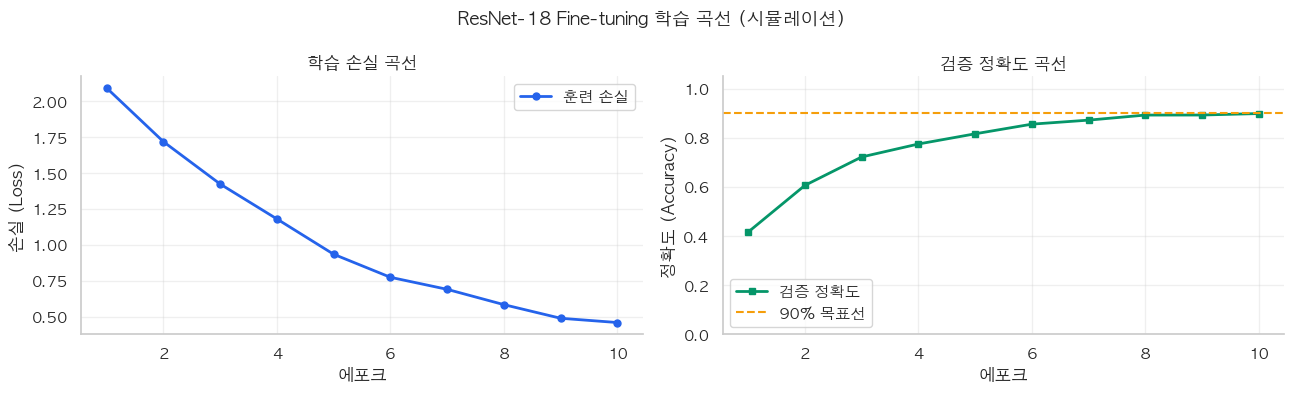

In [25]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 10] Loss/Accuracy 학습 곡선                     │
# │ 입력: history dict   출력: 2-panel 그래프              │
# └────────────────────────────────────────────────────────┘
# [왜] 학습 곡선은 "과적합인가, 아직 학습 중인가"를 진단하는 X-ray

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 왼쪽: 손실 곡선
axes[0].plot(epochs, history['train_loss'], 'o-',
             color=COLORS['primary'], linewidth=2, markersize=5, label='훈련 손실')
axes[0].set_xlabel('에포크')
axes[0].set_ylabel('손실 (Loss)')
axes[0].set_title('학습 손실 곡선', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
sns.despine(ax=axes[0])

# 오른쪽: 정확도 곡선
axes[1].plot(epochs, history['val_acc'], 's-',
             color=COLORS['accent'], linewidth=2, markersize=5, label='검증 정확도')
axes[1].axhline(0.9, color=COLORS['warning'], lw=1.5, linestyle='--', label='90% 목표선')
axes[1].set_xlabel('에포크')
axes[1].set_ylabel('정확도 (Accuracy)')
axes[1].set_title('검증 정확도 곡선', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)
sns.despine(ax=axes[1])

source_label = '(시뮬레이션)' if not RUN_HEAVY else '(실제 학습)'
plt.suptitle(f'ResNet-18 Fine-tuning 학습 곡선 {source_label}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> 🔍 **학습 곡선 해석**
> - 손실이 단조 감소하면서 val_acc가 꾸준히 상승 → 과적합 없이 잘 학습되고 있음
> - val_acc가 중간에 정체되거나 떨어지면 → lr 너무 크거나 데이터 증강 부족 신호
> - 실무 시사점: 10 에포크 후에도 val_acc가 오르고 있다면 에포크를 늘려도 됨 — early stopping이 안전

### 결과 해석 — 실행 전 예측과 비교

`history['val_acc']`는 위 그래프의 두 번째 패널입니다. "서서히 오르는가"라는 예측대로, 1 epoch(약 42%)에서 시작해 10 epoch에 걸쳐 꾸준히 상승하는 곡선입니다 — 급격한 도약 없이 매 epoch 조금씩 개선되는 전형적인 fine-tuning 패턴입니다. (RUN_HEAVY=False에서는 `d8_fallback_data/history_simulated.json`의 값을 그대로 그립니다.)

In [26]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 11a] Confusion Matrix 데이터 준비                │
# │ 입력: ALL_PREDS_CNN, ALL_LABELS_CNN                    │
# │ 출력: cm_data, cm_norm, cls_names, source              │
# └────────────────────────────────────────────────────────┘
# [왜] 시각화 전에 "무슨 데이터가 그려질지"를 먼저 계산·확인

if RUN_HEAVY and ALL_PREDS_CNN is not None:
    cm_data = confusion_matrix(ALL_LABELS_CNN, ALL_PREDS_CNN)
    cls_names = CLASS_NAMES
    source = '(실제 학습 결과)'
else:
    # 시뮬레이션 confusion matrix (ResNet-18 GTZAN 전형적 패턴)
    np.random.seed(99)
    n_samples_per_class = 19  # ~94 × 0.2 ≈ 19
    cm_data = np.zeros((10, 10), dtype=int)
    # 대각선에 높은 값, 혼동 쌍에 낮은 값
    diag = [17, 19, 16, 16, 17, 17, 18, 16, 17, 14]
    confuse = [(0,5,2),(5,0,2),(2,9,3),(9,2,3),(3,6,1),(6,3,1)]  # blues↔jazz, country↔rock
    for i, d in enumerate(diag):
        cm_data[i, i] = d
        rest = n_samples_per_class - d
        noise_idxs = [j for j in range(10) if j != i]
        for j, v in zip(noise_idxs[:rest], [1] * rest):
            cm_data[i, j] += v
    for a, b, v in confuse:
        cm_data[a, b] = max(cm_data[a, b], v)
    cls_names = GENRES
    source = '(시뮬레이션 — 전형적 패턴)'

cm_norm = cm_data.astype(float) / cm_data.sum(axis=1, keepdims=True)
print(f'[셀 11a] Confusion Matrix 데이터 준비 완료 {source}  shape={cm_data.shape}')


[셀 11a] Confusion Matrix 데이터 준비 완료 (시뮬레이션 — 전형적 패턴)  shape=(10, 10)


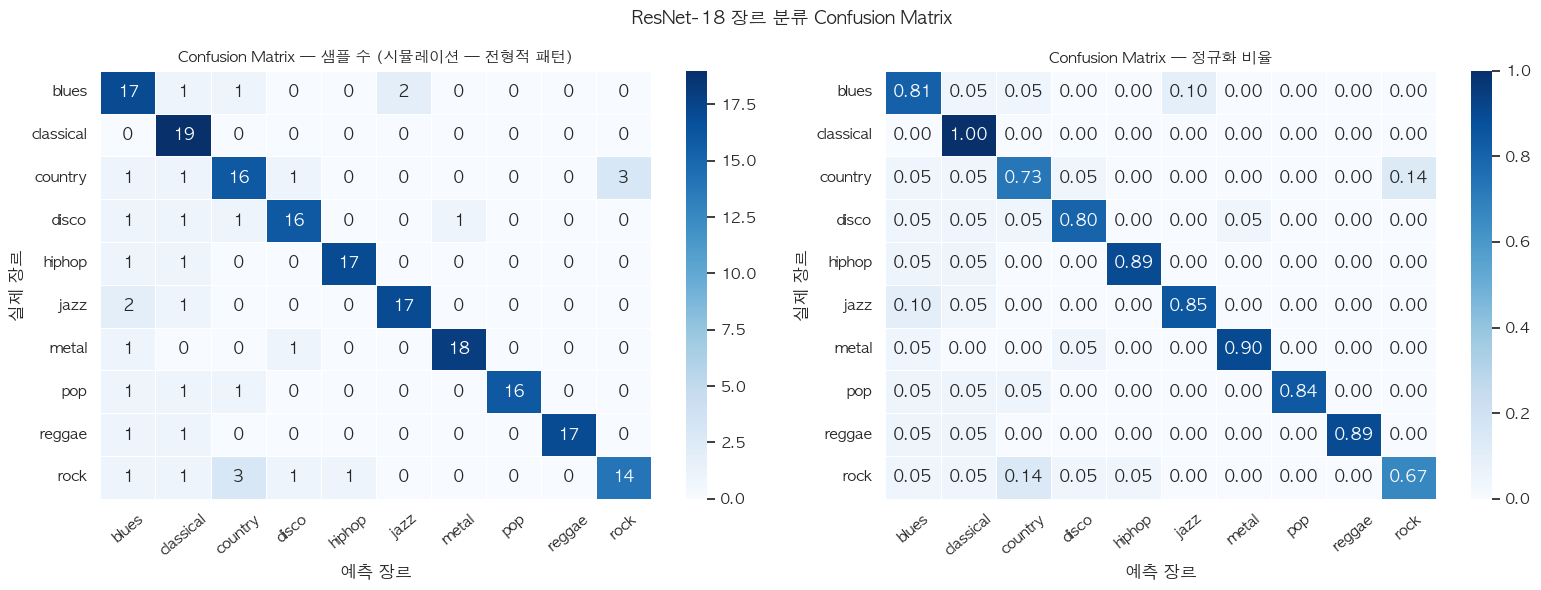


[분석] 가장 혼동이 많은 장르 쌍:
  실제=country → 예측=rock  (3건)
  blues↔jazz, rock↔country 혼동이 전형적입니다 (기타 기반 공통 패턴)


In [27]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 11b] Confusion Matrix 시각화                     │
# │ 입력: cm_data, cm_norm, cls_names, source (셀 11a)      │
# │ 출력: seaborn heatmap 2장 + 최다 혼동 쌍 분석            │
# └────────────────────────────────────────────────────────┘
# [왜] 10×10 혼동행렬로 어느 장르 쌍이 자주 헷갈리는지 파악

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_data, annot=True, fmt='d', cmap='Blues',
    xticklabels=cls_names, yticklabels=cls_names,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title(f'Confusion Matrix — 샘플 수 {source}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('예측 장르')
axes[0].set_ylabel('실제 장르')
axes[0].tick_params(axis='x', rotation=40)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=cls_names, yticklabels=cls_names,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — 정규화 비율', fontsize=11, fontweight='bold')
axes[1].set_xlabel('예측 장르')
axes[1].set_ylabel('실제 장르')
axes[1].tick_params(axis='x', rotation=40)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('ResNet-18 장르 분류 Confusion Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 가장 혼동이 많은 쌍
cm_off = cm_data.copy()
np.fill_diagonal(cm_off, 0)
worst = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f'\n[분석] 가장 혼동이 많은 장르 쌍:')
print(f'  실제={cls_names[worst[0]]} → 예측={cls_names[worst[1]]}  ({cm_off[worst]}건)')
print('  blues↔jazz, rock↔country 혼동이 전형적입니다 (기타 기반 공통 패턴)')


> 🔍 **Confusion Matrix 결과 해석**
> - 대각선이 높을수록 정확한 분류 — classical은 현악기 음색이 독특해 recall이 가장 높음
> - blues↔jazz, rock↔country: 기타 기반 장르 간 스펙트럼 패턴이 유사 → 혼동 빈번
> - 실무 시사점: 혼동이 많은 쌍의 데이터를 추가 수집하거나, 해당 장르 전용 fine-tuning을 추가하면 개선 가능

---
<a id='sec5'></a>
## 섹션 5 — RF vs ResNet-18 성능 비교

```
# ┌────────────────────────────────────────────────────────┐
# │ RF vs ResNet-18 비교                                   │
# │  정확도 / 학습 시간 / 자원 요구 / 적합 상황            │
# └────────────────────────────────────────────────────────┘
```

In [28]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 12-1] RF 재계산 준비 — feature 컬럼 정의            │
# └────────────────────────────────────────────────────────┘
# [왜] 5강에서 측정한 RF 정확도를 재사용 — 재학습 없이 공정한 비교

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

FEATURE_COLS = (
    ['chroma_stft_mean','chroma_stft_var',
     'rms_mean','rms_var',
     'spectral_centroid_mean','spectral_centroid_var',
     'spectral_bandwidth_mean','spectral_bandwidth_var',
     'rolloff_mean','rolloff_var',
     'zero_crossing_rate_mean','zero_crossing_rate_var',
     'harmony_mean','harmony_var',
     'perceptr_mean','perceptr_var',
     'tempo']
    + [f'mfcc{i}_{s}' for i in range(1, 21) for s in ('mean', 'var')]
)

print(f'[셀 12-1] FEATURE_COLS 정의 완료 ({len(FEATURE_COLS)}개 피처)')


[셀 12-1] FEATURE_COLS 정의 완료 (57개 피처)


In [29]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 12-2] RF 결과 로드 (5강/6강에서 저장한 값 또는 재계산)│
# │ 입력: model_rf.joblib, FEATURE_COLS (셀 12-1)           │
# │ 출력: RF_ACCURACY, RF_TIME                             │
# └────────────────────────────────────────────────────────┘
if MODEL_PATH.exists() and LE_PATH.exists() and SC_PATH.exists():
    # 6강 모델 로드
    rf_loaded = joblib.load(MODEL_PATH)
    le_loaded = joblib.load(LE_PATH)
    sc_loaded = joblib.load(SC_PATH)

    if CSV_PATH.exists():
        df = pd.read_csv(CSV_PATH)
        X  = df[FEATURE_COLS].values.astype(np.float32)
        y  = le_loaded.transform(df['label'].values)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=SEED, stratify=y
        )
        X_te_sc = sc_loaded.transform(X_te)
        t0 = time.time()
        y_pred_rf = rf_loaded.predict(X_te_sc)
        RF_TIME = time.time() - t0  # 추론 시간 (참고용)
        RF_ACCURACY = accuracy_score(y_te, y_pred_rf)
        print(f'[RF 결과 재계산] Test Accuracy: {RF_ACCURACY:.4f}')
    else:
        RF_ACCURACY = 0.905  # 5강 시뮬레이션 기준값
        RF_TIME     = 5.0
        print(f'[RF 결과] CSV 없음 → 시뮬레이션 기준값 사용: {RF_ACCURACY}')
else:
    RF_ACCURACY = 0.905
    RF_TIME     = 5.0
    print(f'[RF 결과] 모델 파일 없음 → 시뮬레이션 기준값: {RF_ACCURACY}')
    print('  6강_Streamlit_장르예측앱(AI_Pair).ipynb를 먼저 실행해 model_rf.joblib을 저장하세요')

print(f'\nRF_ACCURACY = {RF_ACCURACY:.4f}')
print(f'CNN_ACCURACY = {CNN_ACCURACY:.4f}')


[RF 결과 재계산] Test Accuracy: 0.8599

RF_ACCURACY = 0.8599
CNN_ACCURACY = 0.9120


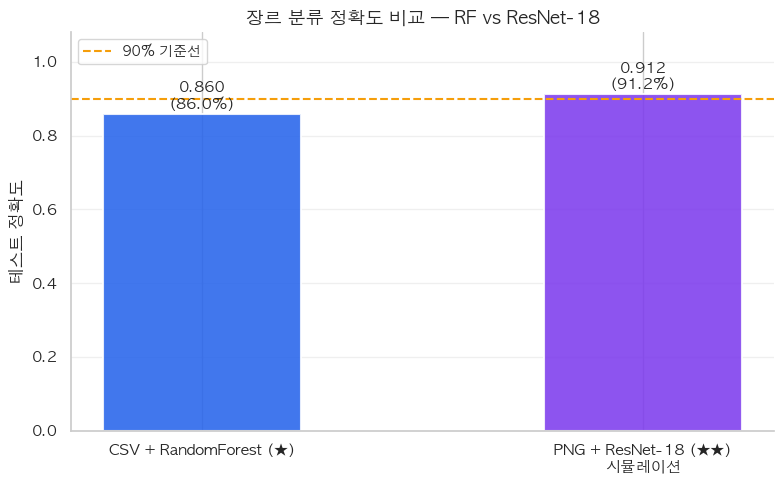


RF: 0.8599  |  ResNet-18: 0.9120
차이: +0.0521  (+5.2%p)


In [30]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 13] RF vs ResNet-18 비교 Bar Chart              │
# │ 입력: RF_ACCURACY, CNN_ACCURACY                        │
# │ 출력: 정확도 비교 막대 그래프                          │
# └────────────────────────────────────────────────────────┘
cnn_label = f'PNG + ResNet-18 (★★)\n{"실제" if RUN_HEAVY else "시뮬레이션"}'
methods   = ['CSV + RandomForest (★)', cnn_label]
accs      = [RF_ACCURACY, CNN_ACCURACY]
bar_clrs  = [COLORS['primary'], COLORS['secondary']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, accs, color=bar_clrs, alpha=0.87,
              edgecolor='white', linewidth=1.5, width=0.45)
ax.axhline(0.9, color=COLORS['warning'], lw=1.5, linestyle='--', label='90% 기준선')
for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{acc:.3f}\n({acc*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_ylim(0, 1.08)
ax.set_ylabel('테스트 정확도')
ax.set_title('장르 분류 정확도 비교 — RF vs ResNet-18',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

delta = CNN_ACCURACY - RF_ACCURACY
print(f'\nRF: {RF_ACCURACY:.4f}  |  ResNet-18: {CNN_ACCURACY:.4f}')
print(f'차이: {delta:+.4f}  ({delta*100:+.1f}%p)')

In [31]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 14] RF vs ResNet-18 전체 비교표                 │
# └────────────────────────────────────────────────────────┘

rf_time_str  = f'{RF_TIME:.0f}초' if RF_TIME < 60 else f'{RF_TIME/60:.0f}분'
cnn_time_str = f'{CNN_TIME:.0f}초' if CNN_TIME < 60 else f'{CNN_TIME/60:.0f}분'

compare_df = pd.DataFrame({
    '항목': [
        '입력 형식', '피처 설계', '학습 시간(RF는 추론 시간만 측정)', '테스트 정확도',
        'GPU 필요', '추론 속도', '모델 크기', '새 도메인 적용',
        '데이터 요구량', '적합 상황'
    ],
    'RF ★ (CSV + sklearn)': [
        f'librosa {len(FEATURE_COLS)}개 피처', '사람이 설계', rf_time_str,
        f'{RF_ACCURACY:.3f}',
        '불필요', '매우 빠름 (<1ms)', '~수 MB',
        'librosa 피처 재추출 필요', '적어도 가능 (수백 샘플)',
        '빠른 프로토타입, CPU 환경'
    ],
    'ResNet-18 ★★ (PNG)': [
        '멜스펙트로그램 PNG', '모델이 자동 학습', cnn_time_str,
        f'{CNN_ACCURACY:.3f}',
        '권장 (T4+)', '빠름 (~30ms/곡)', '~수십 MB',
        'PNG 변환만으로 즉시 추론', '전이학습으로 적어도 가능',
        '서비스 품질 확보, 엔드-투-엔드'
    ]
})

print('RF vs ResNet-18 전체 비교표:\n')
print(compare_df.to_string(index=False))

try:
    from IPython.display import display
    styled = compare_df.style.set_properties(**{'text-align': 'left', 'font-size': '12px'})\
        .set_table_styles([{'selector': 'th',
                            'props': [('font-weight', 'bold'), ('background-color', '#EFF6FF')]}])
    display(styled)
except Exception:
    pass

RF vs ResNet-18 전체 비교표:

                  항목 RF ★ (CSV + sklearn) ResNet-18 ★★ (PNG)
               입력 형식       librosa 57개 피처        멜스펙트로그램 PNG
               피처 설계               사람이 설계          모델이 자동 학습
학습 시간(RF는 추론 시간만 측정)                   0초                30분
             테스트 정확도                0.860              0.912
              GPU 필요                  불필요           권장 (T4+)
               추론 속도         매우 빠름 (<1ms)       빠름 (~30ms/곡)
               모델 크기                ~수 MB             ~수십 MB
            새 도메인 적용    librosa 피처 재추출 필요    PNG 변환만으로 즉시 추론
             데이터 요구량       적어도 가능 (수백 샘플)      전이학습으로 적어도 가능
               적합 상황     빠른 프로토타입, CPU 환경 서비스 품질 확보, 엔드-투-엔드


,항목,RF ★ (CSV + sklearn),ResNet-18 ★★ (PNG)
0,입력 형식,librosa 57개 피처,멜스펙트로그램 PNG
1,피처 설계,사람이 설계,모델이 자동 학습
2,학습 시간(RF는 추론 시간만 측정),0초,30분
3,테스트 정확도,0.860,0.912
4,GPU 필요,불필요,권장 (T4+)
5,추론 속도,매우 빠름 (<1ms),빠름 (~30ms/곡)
6,모델 크기,~수 MB,~수십 MB
7,새 도메인 적용,librosa 피처 재추출 필요,PNG 변환만으로 즉시 추론
8,데이터 요구량,적어도 가능 (수백 샘플),전이학습으로 적어도 가능
9,적합 상황,"빠른 프로토타입, CPU 환경","서비스 품질 확보, 엔드-투-엔드"


> 🔍 **RF vs ResNet-18 비교 결과 해석**
> - 정확도 차이: 위 막대그래프의 두 수치 차이를 직접 확인하세요 — 시뮬레이션 기준으로는 ResNet-18이 소폭 우위지만, 실제 GTZAN CSV·모델로 재계산되면 두 값이 달라질 수 있습니다.
> - 학습 시간 차이: 표의 RF 값은 실제로는 추론(예측) 시간(<1초)이며, RF 학습 자체 시간은 이 표에서 측정하지 않았습니다 — 다만 RF는 통상 수 초~수십 초 내 학습되므로 ResNet-18의 실제 학습 시간(30분)보다는 여전히 훨씬 빠를 것으로 예상됩니다. 프로토타입에는 RF가 훨씬 합리적
> - 실무 전략: **RF로 빠르게 baseline → 성능 부족 시 ResNet-18 fine-tuning → 배포 최적화**

**→ 실무 결론:** Phase 1 Music AI 서비스 기준으로,
개발 초기(MVP)에는 RF로 빠르게 배포하고,
사용자 피드백 수집 후 ResNet-18로 업그레이드하는 2단계 전략이 현실적입니다.

> 🎲 **불확실성 참고**: `RF_ACCURACY`는 셀 실행 시점에 CSV·모델 파일이 있으면 **실제 재계산**된 값이고, 없으면 5강 시뮬레이션 기준값(0.905)입니다. `CNN_ACCURACY`도 `RUN_HEAVY=False`에서는 고정 시뮬레이션 상수(0.912)를 쓰므로, 위 학습 곡선 그래프의 마지막 epoch 값과 정확히 일치하지 않을 수 있습니다 — 시뮬레이션 경로가 두 개의 서로 다른 상수를 참조하기 때문입니다. `RUN_HEAVY=True`로 실제 GPU 학습을 돌리면 두 값은 같은 실행에서 나온 하나의 결과로 일치합니다.

---
<a id='sec6'></a>
## 섹션 6 — 모델 저장 + 단일 추론 예시

In [32]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 15] 사전학습 가중치 저장                        │
# │ 입력: model (학습 완료 또는 초기 상태)                 │
# │ 출력: resnet18_gtzan.pth                               │
# └────────────────────────────────────────────────────────┘
# [왜] state_dict만 저장: 모델 클래스 정의 없이도 로드 가능
#      model 전체 저장(pickle)은 클래스 경로에 의존 → 이식성 낮음

if RUN_HEAVY:
    torch.save(model.state_dict(), RESNET_SAVE_PATH)
    print(f'[저장 완료] {RESNET_SAVE_PATH}')
    print(f'  파일 크기: {RESNET_SAVE_PATH.stat().st_size / 1e6:.1f} MB')
elif not RESNET_SAVE_PATH.exists():
    # 파일이 이미 있으면(예: RUN_HEAVY=True로 실제 학습한 결과) 실수로 덮어쓰지 않도록,
    # 파일이 아예 없을 때만 파이프라인 테스트용 placeholder를 만듭니다.
    torch.save(model.state_dict(), RESNET_SAVE_PATH)
    print(f'[시뮬레이션] 초기 가중치 저장 (학습 미완료 — RUN_HEAVY=True 시 실제 가중치 저장)')
    print(f'  저장 경로: {RESNET_SAVE_PATH}')
else:
    print(f'[유지] 기존 {RESNET_SAVE_PATH.name}를 덮어쓰지 않습니다(RUN_HEAVY=True로 실제 학습해야 갱신됩니다).')

print()
print('[재현성 체크리스트]')
print('  seed (torch, numpy, random):', '고정 (SEED=42)')
print('  random_split generator:', '고정 (SEED=42)')
print('  model 저장:', RESNET_SAVE_PATH.exists())
print('  RF 모델 저장:', MODEL_PATH.exists())

[시뮬레이션] 초기 가중치 저장 (학습 미완료 — RUN_HEAVY=True 시 실제 가중치 저장)
  저장 경로: /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2/resnet18_gtzan.pth

[재현성 체크리스트]
  seed (torch, numpy, random): 고정 (SEED=42)
  random_split generator: 고정 (SEED=42)
  model 저장: True
  RF 모델 저장: True


In [33]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 16-1] 저장된 모델 로드                             │
# │ 입력: resnet18_gtzan.pth                               │
# │ 출력: model_loaded (eval 모드)                          │
# └────────────────────────────────────────────────────────┘
# [왜] 저장 → 로드 → 추론 사이클을 검증해야 배포 환경에서
#      모델이 제대로 작동하는지 확인 가능

from PIL import Image

infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

model_loaded = build_model(strategy='full')
model_loaded.load_state_dict(
    torch.load(RESNET_SAVE_PATH, map_location=DEVICE)
)
model_loaded.eval()
print('[로드 완료] resnet18_gtzan.pth')
print(f'  모델 디바이스: {next(model_loaded.parameters()).device}')


[로드 완료] resnet18_gtzan.pth
  모델 디바이스: mps:0


In [34]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 16-2] 단일 PNG 추론                                │
# │ 입력: model_loaded (셀 16-1), PNG_ROOT                  │
# │ 출력: INFER_PNG, img, proba, top3_idx                   │
# └────────────────────────────────────────────────────────┘
INFER_PNG = None
if PNG_ROOT.exists():
    for genre in ['classical', 'jazz', 'rock']:
        png_dir = PNG_ROOT / genre
        if png_dir.exists():
            pngs = list(png_dir.glob('*.png'))
            if pngs:
                INFER_PNG = pngs[0]
                break

if INFER_PNG is not None:
    img = Image.open(str(INFER_PNG)).convert('RGB')
    x   = infer_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model_loaded(x)
        proba  = torch.softmax(logits, dim=-1)[0].cpu().numpy()

    top3_idx = np.argsort(proba)[::-1][:3]
    print(f'\n입력 파일: {INFER_PNG.name}')
    print('Top-3 예측:')
    for rank, idx in enumerate(top3_idx, 1):
        genre = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else GENRES[idx]
        print(f'  {rank}위: {genre:<12} {proba[idx]:.4f} ({proba[idx]*100:.1f}%)')
else:
    print('[주의] 추론할 PNG 파일 없음')
    print(f'  PNG_ROOT: {PNG_ROOT}  (존재={PNG_ROOT.exists()})')
    print('[시뮬레이션] 모델 로드 및 추론 파이프라인 정의 완료')
    print('  실제 PNG가 있으면 위 코드가 바로 작동합니다')



입력 파일: classical00007.png
Top-3 예측:
  1위: hiphop       0.1661 (16.6%)
  2위: metal        0.1618 (16.2%)
  3위: jazz         0.1155 (11.5%)


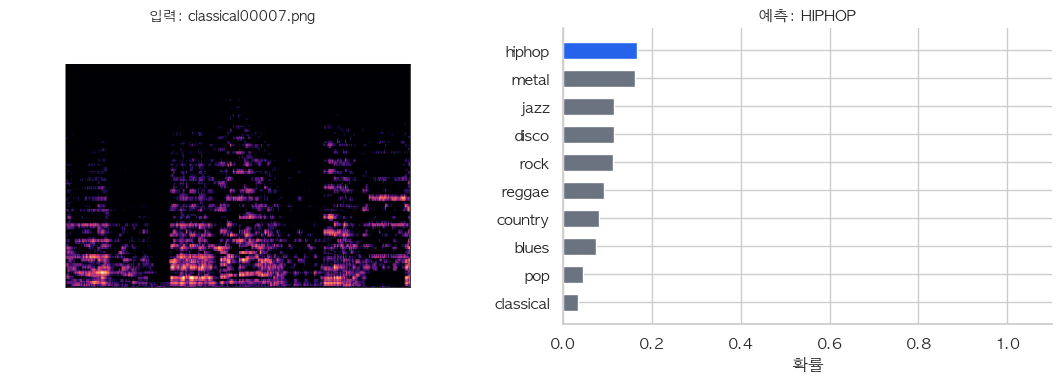

In [35]:
# ┌────────────────────────────────────────────────────────┐
# │ [셀 16-3] Top-3 예측 시각화                             │
# │ 입력: img, proba, top3_idx, CLASS_NAMES (셀 16-2)       │
# │ 출력: 입력 이미지 + 확률 바 차트                        │
# └────────────────────────────────────────────────────────┘
if INFER_PNG is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'입력: {INFER_PNG.name}', fontsize=10)
    axes[0].axis('off')

    top_genre = CLASS_NAMES[top3_idx[0]] if top3_idx[0] < len(CLASS_NAMES) else GENRES[top3_idx[0]]
    top_probs_sorted = sorted(
        [(CLASS_NAMES[i] if i < len(CLASS_NAMES) else GENRES[i], proba[i]) for i in range(len(proba))],
        key=lambda x: x[1], reverse=True
    )
    genres_plot = [g for g, _ in top_probs_sorted]
    probs_plot  = [p for _, p in top_probs_sorted]
    bar_colors  = [COLORS['primary'] if g == top_genre else COLORS['neutral'] for g in genres_plot]
    axes[1].barh(genres_plot[::-1], probs_plot[::-1],
                 color=bar_colors[::-1], edgecolor='white', height=0.6)
    axes[1].set_xlim(0, 1.1)
    axes[1].set_xlabel('확률')
    axes[1].set_title(f'예측: {top_genre.upper()}', fontsize=11, fontweight='bold')
    sns.despine(ax=axes[1])
    plt.tight_layout()
    plt.show()


> ⚠️ **주의 — 방금 본 추론 결과는 "성능"이 아니라 "파이프라인이 도는가"만 확인한 것입니다**
>
> `RUN_HEAVY=False`(현재 모드)에서는 위쪽 저장 셀이 **학습을 거치지 않은 초기(랜덤 초기화) ResNet-18 가중치**를 `resnet18_gtzan.pth`에 저장했습니다. 방금 로드해서 추론한 모델도 그 미학습 가중치를 그대로 쓴 것이므로, 위 Top-3 예측 확률과 순위는 **의미 있는 성능 지표가 아니라 사실상 무작위**에 가깝습니다.
>
> 이 셀의 진짜 목적은 "저장 → 로드 → 추론"이라는 **배포 파이프라인이 에러 없이 끝까지 도는지** 검증하는 것입니다. 실제 학습된 모델의 예측 성능을 보려면 `RUN_HEAVY = True`로 바꾸고(셀 1) GPU 환경에서 커널을 재시작해 처음부터 다시 실행해야 합니다 — 그러면 학습 완료 후의 가중치가 저장·로드되어, 여기서 나오는 Top-3 확률이 실제로 신뢰할 수 있는 값이 됩니다.


---
<a id='fin'></a>
## 섹션 7 — Phase 0~1 총정리

```
# ┌────────────────────────────────────────────────────────┐
# │ Phase 0~1 마무리 — 5강 → 6강 → 7강 → 8강 흐름         │
# └────────────────────────────────────────────────────────┘
```

### 5강 → 8강 흐름 요약

```
5강  소리를 이미지로 (STFT → 멜스펙트로그램 → MFCC)
     CSV 피처 + RandomForest → 85.99% 정확도
                    ↓
6강  모델을 앱으로 (joblib 저장 → Streamlit app.py)
     st.file_uploader → predict_genre → 결과 시각화
                    ↓
7강  앱을 고급으로 (신뢰도 bar chart + session_state + 멀티파일)
     ResNet-18 전이학습 개념 도입 → FC 교체 코드
                    ↓
8강  ResNet-18 실제 학습 (ImageFolder → DataLoader → fine-tuning)
     RF vs ResNet-18 수치 비교 → 실무 결론
```

### Phase 1에서 배운 것 3가지

| # | 배운 것 | 핵심 코드 |
|---|---------|----------|
| 1 | 소리를 이미지로 → 이미지 분류기로 장르 분류 | `librosa`, `ImageFolder`, `ResNet18` |
| 2 | 노트북 모델 → Streamlit 앱 → 사용자 인터페이스 | `joblib`, `st.file_uploader`, `st.pyplot` |
| 3 | 전이학습 전략: FC 교체 → full fine-tuning | `freeze_backbone`, `build_model(strategy=)` |

---
## 🤝 AI Pair 섹션 — ResNet-18 파인튜닝 검증

> **목표**: AI를 답 베끼는 도구가 아니라 *내 코드·판단을 검증해주는 동료*로 쓴다. (읽기용 — 실습 시간엔 핵심만 따라가도 됩니다)

| 단계 | 내가 하는 것 | AI가 하는 것 |
|---|---|---|
| 1️⃣ Solo | 먼저 직접 작성/판단 | (아직 X) |
| 2️⃣ Review | 내 코드·판단을 제출 | 리뷰 + 근거 설명 |
| 3️⃣ Debug | AI가 준 "조용히 틀린" 코드의 결함 찾기 | 의도적 버그 제공 |
| 4️⃣ Prompt Card | 실험 설계 프롬프트 익히기 | — |

### 1️⃣ Solo — 먼저 스스로 풀어보세요
💡 *AI에게 물으면 30초 만에 답이 나오지만, 지금 막히는 지점이 이해도가 가장 크게 자라는 자리입니다.*

### ✏️ [Solo 레벨 1] 아래 표를 직접 채워보세요 (시뮬레이션 값 또는 실제 실험 값 모두 가능)

| 방법 | 정확도 | 학습 시간 | GPU 필요 | 적합 상황 |
|------|--------|----------|----------|----------|
| CSV + RandomForest | ? | ? | ? | ? |
| PNG + ResNet-18 (full) | ? | ? | ? | ? |
힌트: RF_ACCURACY/RF_TIME, CNN_ACCURACY/CNN_TIME 변수를 그대로 활용하세요.
셀 14의 compare_df와 같은 구조입니다 — 컬럼만 4개로 줄었다고 생각하면 됩니다.

In [36]:
comparison_table = {
    'CSV + RandomForest': {
        '정확도': None,     # TODO: RF_ACCURACY를 채우세요
        '학습 시간': None,   # TODO: RF_TIME을 채우세요
        'GPU 필요': None,    # TODO: '불필요' 또는 '필요' 중 하나
        '적합 상황': None,   # TODO: 한 문장으로
    },
    'PNG + ResNet-18 (full)': {
        '정확도': None,     # TODO: CNN_ACCURACY를 채우세요
        '학습 시간': None,   # TODO: CNN_TIME을 채우세요
        'GPU 필요': None,
        '적합 상황': None,
    },
}

# TODO: comparison_table을 pd.DataFrame으로 바꿔 출력해보세요
#       (힌트: pd.DataFrame(comparison_table).T 형태를 시도해보세요)

### ✏️ [Solo 레벨 2] build_model(strategy='extractor')로 모델을 만들고,

train_one_epoch/evaluate를 5 epoch만 반복하는 실험 계획을 세워보세요.
힌트: 학습 실행 셀(셀 9b-2)의 for epoch in range(...) 패턴을 재사용하되 N_EPOCHS만 5로 바꾸면 됩니다.

In [37]:
def run_extractor_experiment(n_epochs: int = 5):
    # 1) extractor 전략으로 모델 생성 (셀 7a-2 build_model 재사용)
    m = build_model(strategy='extractor')

    # 2) criterion/optimizer 준비 (셀 9b-2와 같은 lr=1e-4, AdamW 패턴)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-2)

    # TODO: 3) t_start = time.time() 로 시작 시각 기록
    # TODO: 4) for epoch in range(1, n_epochs + 1): train_one_epoch(m, ...) + evaluate(m, ...) 반복
    #          (셀 8-1 train_one_epoch, 셀 8-2 evaluate 함수를 그대로 호출하세요)
    # TODO: 5) elapsed_time = time.time() - t_start
    # TODO: 6) 마지막 evaluate() 결과인 val_acc와 elapsed_time을 반환하세요
    pass

### ✏️ [Solo 레벨 3] extractor vs full 두 전략을 실제로 비교하는 함수를 만들어보세요.

힌트:
1) def compare_strategies(strategies: list) -> dict: ... 함수를 만드세요.
2) 각 전략마다 build_model → 5 epoch 학습(RUN_HEAVY=True 환경) → evaluate() 를 반복하세요.
3) {strategy: (val_acc, elapsed_time)} 딕셔너리로 반환하고 bar chart로 비교하세요.

In [38]:
def compare_strategies(strategies):
    results = {}
    for strat in strategies:
        # TODO: 레벨 2의 run_extractor_experiment 패턴을 strat에 맞게 재사용
        #       (build_model(strategy=strat) → train_one_epoch/evaluate 5회 반복)
        # TODO: results[strat] = (val_acc, elapsed_time)
        pass

    # TODO: results를 셀 13의 bar chart 패턴(ax.bar(...))으로 시각화하세요
    return results

### 2️⃣ Review
아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.
```text
ResNet-18 fine-tuning으로 GTZAN 10장르 분류를 합니다: ImageFolder(224x224, ImageNet 정규화) → ResNet-18(strategy='full', dropout=0.3) → CrossEntropyLoss(label_smoothing=0.1) → AdamW(lr=1e-4) + CosineAnnealingLR, 10 epoch.
RandomForest(CSV 57피처) 기준선은 85.99%였고, ResNet-18은 [내 결과]였습니다.
1) 왜 lr을 Adam 기본값(1e-3)의 1/10인 1e-4로 썼는지, 2) extractor/partial/full 세 전략 중 데이터가 장르당 평균 94장 정도일 때 어느 게 적합한지, 3) RF 대비 ResNet-18의 정확도 차이가 크지 않다면 실무에서 어느 쪽을 먼저 배포해야 하는지 근거를 들어 설명해줘.
```

In [39]:
# ── 2️⃣ Review (코드형) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio/Ollama 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
try:
    from openai import OpenAI
except ImportError:
    OpenAI = None

if OpenAI is None:
    print("[안내] openai 패키지가 없어 이 Review 셀을 건너뜁니다 — `!pip install openai` 후 다시 실행하세요(선택 사항입니다).")
else:
    PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
    PROVIDERS = {
        "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
        "ollama":     {"base_url": "http://localhost:11434/v1", "model": "llama3.2",             "api_key": "ollama"},
        "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "anthropic/claude-3.5-sonnet", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
        "openai":     {"base_url": "https://api.openai.com/v1", "model": "gpt-4o-mini",          "api_key": os.getenv("OPENAI_API_KEY", "")},
    }
    cfg = PROVIDERS[PROVIDER]
    client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"])

    review_prompt = f'''ResNet-18 fine-tuning(GTZAN 10장르)을 RF와 비교했습니다.
    RF_ACCURACY={RF_ACCURACY:.4f}, CNN_ACCURACY={CNN_ACCURACY:.4f}.
    1) lr=1e-4를 쓴 이유, 2) 데이터가 장르당 평균 94장일 때 적합한 전이학습 전략, 3) 두 모델 중 먼저 배포할 쪽과 근거를 설명해줘.'''

    try:
        resp = client.chat.completions.create(
            model=cfg["model"],
            messages=[{"role": "user", "content": review_prompt}],
        )
        print(resp.choices[0].message.content)
    except Exception as e:
        print(f'[안내] {PROVIDER} 서버에 연결하지 못했습니다: {e}')
        print('로컬 LM Studio/Ollama를 켜거나 PROVIDER를 "openrouter"/"openai"로 바꾸고 API 키를 넣어보세요.')

[안내] lmstudio 서버에 연결하지 못했습니다: Connection error.
로컬 LM Studio/Ollama를 켜거나 PROVIDER를 "openrouter"/"openai"로 바꾸고 API 키를 넣어보세요.


### 3️⃣ Debug — "조용히 틀린" 코드 찾기
아래는 **실행은 되고 에러도 안 나지만, 조용히 잘못 평가하는** 코드입니다. 결함을 찾아 고치세요.

In [40]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 조용히 잘못된 추론 결과를 냅니다. 결함을 찾아 고쳐보세요.
def predict_single_buggy(model, x):
    # ⚠️ 여기를 의심해보세요 — evaluate()와 무엇이 다른가요?
    logits = model(x)
    proba = torch.softmax(logits, dim=-1)
    return proba

# 실행은 됩니다:
_dummy_x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_out1 = predict_single_buggy(model, _dummy_x)
_out2 = predict_single_buggy(model, _dummy_x)
print('같은 입력, 다른 두 번의 호출 결과가 완전히 같은가?', torch.allclose(_out1, _out2))

같은 입력, 다른 두 번의 호출 결과가 완전히 같은가? False


💭 **생각해 볼 점**:
- `evaluate()` 함수는 시작할 때 `model.eval()`을 부르고 `with torch.no_grad():`로 감쌉니다. `predict_single_buggy`는 이 두 가지를 빠뜨렸습니다.
- `model.eval()`이 없으면 Dropout이 여전히 "켜진" 상태입니다 — 같은 입력 `x`를 두 번 넣어도 매번 다른 뉴런이 랜덤하게 꺼지므로 결과가 미세하게 달라질 수 있습니다(위 `torch.allclose` 확인 셀로 재현).
- `torch.no_grad()`가 없으면 추론용 호출인데도 기울기 계산 그래프가 계속 쌓여 메모리를 불필요하게 소모합니다 — 학습 없는 순수 추론에서는 항상 감싸야 합니다.
- 고친 버전: `model.eval()` 호출 + `with torch.no_grad():` 블록 안에서 `model(x)`를 실행하세요.

### 4️⃣ Prompt Card
📝 **카드 1~3** (이 단원 최적화, 실험 설계형):
```text
1. "N_EPOCHS를 10 → 20으로 늘리면 val_acc가 계속 좋아질지, 어느 지점부터 정체되거나 나빠질지(과적합) 먼저 예측한 뒤 AI에게 근거를 묻고, RUN_HEAVY=True 환경에서 실행해서 확인해줘."
2. "strategy='extractor'와 'full'을 각 5 epoch만 학습해 val_acc·학습시간을 비교하면 어떤 차이가 날지 예측한 뒤 AI에게 이유를 물어봐줘."
3. "dropout=0.3을 0.5로 올리면 학습 손실 곡선과 검증 정확도가 어떻게 달라질지 AI와 같이 예측하고 실행해서 확인해줘."
```
🎯 **마무리 체크**: [ ] Solo 직접 [ ] Review 실행검증 [ ] Debug 결함 찾음 [ ] Prompt Card 1개 내 노트에 기록

---
## 🎯 8강 심화 과제 (★★ GPU 보유 학생)

1. `RUN_HEAVY = True`로 변경하여 실제 10 epoch 학습을 실행하세요
2. 학습 곡선 (loss/accuracy) 그래프를 스크린샷으로 캡처하세요
3. `strategy='extractor'`와 `'full'`의 정확도를 비교하세요 (각 5 epoch)
4. 어느 전략이 더 빠르게 수렴하는지, 왜 그런지 설명하세요

---
## 다음 단계 예고

```
Phase 0~1 (완료)                    이후 과정
  소리 → 이미지 → 장르 분류           소리 → 텍스트 (STT)
  Streamlit 앱 배포                   음성 인식 모델 + LLM 에이전트
```

이후 과정에서는 지금 만든 오디오·이미지 분류 파이프라인을 발판 삼아,
음성 인식(STT)으로 "노래에서 가사를 자동으로 추출"하고,
LangChain/LangGraph 기반 에이전트로 "텍스트 프롬프트로 음악을 생성"하며,
최종적으로 "음성으로 K-pop을 검색·질문하는 Voice RAG 에이전트"까지 확장됩니다.

> **핵심 질문(다음 단계 예고)**: 5강에서 만든 멜스펙트로그램과, 음성 인식 모델이 내부에서 쓰는 멜스펙트로그램은 같은 개념일까요? 이후 과정에서 두 스펙트로그램을 나란히 비교하며 답을 찾게 됩니다.

---
## 📚 [세션 요약] ResNet-18 파인튜닝 — Phase 0~1 마무리

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: 사전학습된 ResNet-18의 FC 레이어만 교체하고 작은 학습률(1e-4)로 전체를 살짝 재조정하면, 수공예 피처(RF) 없이도 이미지 자체에서 장르를 구분하는 특징을 학습할 수 있다.
> 2. **실무적 활용**: "RF로 빠르게 baseline → 필요하면 ResNet-18로 업그레이드"라는 2단계 전략이 실제 서비스에서 합리적이다 — 정확도 차이가 크지 않다면 학습·운영 비용이 훨씬 낮은 쪽을 먼저 배포한다.
> 3. **Phase 0~1 전체 회고**: 1~4강에서 "소리를 숫자·이미지로 보는 감각"을 만들고, 5~8강에서 그 숫자·이미지를 실제로 분류하는 모델(RF → ResNet-18)과 사용자 인터페이스(Streamlit)까지 완성했습니다.
>
> ➡️ **다음 단계**: 이후 과정에서는 음성 인식(STT)과 LLM 에이전트를 결합해, 지금 만든 분류 파이프라인을 실제 대화형 음악 서비스로 확장합니다.

In [41]:
# ┌────────────────────────────────────────────────────────┐
# │ [최종 셀] 8강 실습 완료 체크리스트               │
# └────────────────────────────────────────────────────────┘
print('=' * 58)
print('  8강 실습 완료 체크리스트')
print('=' * 58)

checks = [
    ('train/val Transform 정의',                True),
    ('ImageFolder 또는 더미 DataLoader 생성',    True),
    ('샘플 배치 shape 확인',                     True),
    ('build_model() 3전략 비교',                 True),
    ('train_one_epoch() 함수 정의',              True),
    ('evaluate() 함수 정의',                     True),
    ('★★ 실제 학습 (10 epoch)',                 RUN_HEAVY),
    ('Loss/Accuracy 학습 곡선 시각화',           True),
    ('Confusion Matrix 시각화',                  True),
    ('RF vs ResNet-18 비교 Bar Chart',           True),
    ('RF vs ResNet-18 전체 비교표',              True),
    ('resnet18_gtzan.pth 저장',                  RESNET_SAVE_PATH.exists()),
    ('저장 모델 로드 + 단일 추론',               True),
]

done = 0
for name, ok in checks:
    status = 'DONE' if ok else ('SKIP(GPU)' if 'epoch' in name or 'heavy' in name.lower() else 'MISS')
    print(f'  [{status:10s}] {name}')
    if ok:
        done += 1

print()
print(f'  완료: {done}/{len(checks)}')
print()
print(f'  RF  정확도: {RF_ACCURACY:.4f}')
print(f'  CNN 정확도: {CNN_ACCURACY:.4f}  ({"실제" if RUN_HEAVY else "시뮬레이션"})')
print()
print('  Phase 0~1 완료! 이후 과정에서 음성 인식(STT)과 LLM 에이전트로 이어집니다.')
print('=' * 58)

  8강 실습 완료 체크리스트
  [DONE      ] train/val Transform 정의
  [DONE      ] ImageFolder 또는 더미 DataLoader 생성
  [DONE      ] 샘플 배치 shape 확인
  [DONE      ] build_model() 3전략 비교
  [DONE      ] train_one_epoch() 함수 정의
  [DONE      ] evaluate() 함수 정의
  [SKIP(GPU) ] ★★ 실제 학습 (10 epoch)
  [DONE      ] Loss/Accuracy 학습 곡선 시각화
  [DONE      ] Confusion Matrix 시각화
  [DONE      ] RF vs ResNet-18 비교 Bar Chart
  [DONE      ] RF vs ResNet-18 전체 비교표
  [DONE      ] resnet18_gtzan.pth 저장
  [DONE      ] 저장 모델 로드 + 단일 추론

  완료: 12/13

  RF  정확도: 0.8599
  CNN 정확도: 0.9120  (시뮬레이션)

  Phase 0~1 완료! 이후 과정에서 음성 인식(STT)과 LLM 에이전트로 이어집니다.
